# Code
## Forward Inhibition Function

Here is how an inhibitor impacts on an otherwise constant reaction rate. 

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def inhibitory_kinetics(I, k_max, K_m, m):
    """
    Inhibitory kinetics controlled by an exponent
    I: inhibitor concentration
    k_max: maximum reaction rate
    K_m: Michaelis constant
    m: inhibition coefficient
    """
    rate = k_max / (K_m + I**m)

    return rate

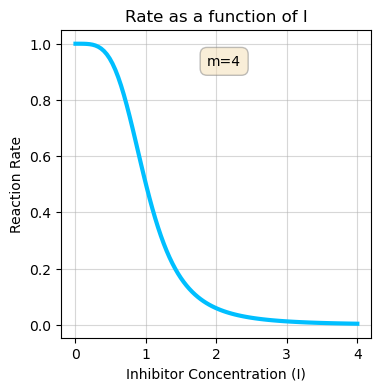

In [2]:
# Constants
K_m   = 1
k_max = 1
m     = 4    # inhibition coefficient 

# Range of substrate values
I_min, I_max = 0, 4
values = 100
I_vals = np.linspace(I_min, I_max, values)

# Calculation of the rate for all values of S
rate = inhibitory_kinetics(I_vals, k_max, K_m, m)


# --- Plot 1: line plots of fucntion ---
fig, ax1 = plt.subplots(figsize=(4, 4))

ax1.plot(I_vals, rate, color='deepskyblue', linewidth=3)
# ax1.vlines(1, 0, k_max, 'gray', linestyles='dotted')
# ax1.hlines(k_max/2, 0, I_max, 'gray', linestyles='dashed')

ax1.set_xlabel('Inhibitor Concentration (I)')
ax1.set_ylabel('Reaction Rate')
ax1.set_title('Rate as a function of I')
ax1.grid(True, alpha=0.5)


# Textbox 1
textstr = f'm={m}'

# Define the style of the textbox using a dictionary
props = dict(
    boxstyle='round,pad=0.5', 
    facecolor='wheat', 
    alpha=0.5, 
    edgecolor='gray'
)

# Place the text box in the upper left of the axes
ax1.text(
    0.47, 0.92, textstr, 
    transform=ax1.transAxes, 
    fontsize=10,
    verticalalignment='top', 
    bbox=props
);


In [3]:
# solve_ivp: numerical ODE integrator, used below to simulate S(t)
from scipy.integrate import solve_ivp
# subplots: matplotlib helper for creating figure/axes grids
from matplotlib.pyplot import subplots
# linspace: evenly spaced sample points; around/var/ndarray: small numeric
# helpers used in later analysis cells
from numpy import linspace, around, var, ndarray
# find_peaks: detect local maxima in a time series (useful for spotting
# oscillations - kept here for consistency with notebook 03)
from scipy.signal import find_peaks

## Feedforward inhibition in Open Flow

The cell below defines a variant of our  model: a single ODE for the substrate $S$, with constant influx, linear removal, and the same forward-inhibition kinetics used for the rate surfaces above. This is the "open flow" system referred to in the introduction to this section.

Here is the mathematical notation:

$$ rate = k_{max} \cdot S^n /( K_m + S^m)$$
$$ \frac{dS}{dt}  = a_s - b_s \cdot S - rate$$
$$ \frac{dP}{dt}  = a_p - b_p \cdot P + rate$$

Compared to the open flow model with Hill kinetics, the only change is that the exponent in the numerator and the denominator are not identical anymore. 

This simple change allows a qualitatively new dynamic feature to appear in the model. It is the simplest case of a self-organised behaviour that only happens when the model is not only nonlinear but has the specific type of nonlinearity which we just introduced. 

Here is the model function followed by the code to use the function for integration. 

In [4]:
def model(t, S, a_s, b_s, a_p, b_p, k_max, K_m, n, m):
    """Enzymatic Reaction with forward inhibition

    This is a 1-variable reduction of the 2-variable model used in
    the notebook on enzymatic oscillations: here we track only the substrate S
    and ignore the downstream product P because it is not having an effect on the rate. This is a simplifying assumption, not necessarily the reality. a2 and b2 are accepted as
    arguments (so the function signature matches the 2-variable version)
    but are not used in the right-hand side below.

    t    : time (unused, but required by solve_ivp's function signature)
    S    : current substrate concentration
    a1   : constant input/production rate of S (the "control parameter"
           we vary throughout this notebook)
    b1   : linear removal rate of S (e.g. dilution, degradation)
    k_max, K_m, n, m : Hill/Haldane kinetics parameters, as in the
           kinetics() function above (forward inhibition: m > n)
    """

    # Nonlinear consumption of S by the enzyme, including forward
    # (substrate) inhibition at high S - same functional form as
    # kinetics(S, k_max, K_m, n, m) used earlier for the rate surfaces.
    enzymatic_rate = k_max * S**n / (K_m + S**m)

    # Net rate of change of S: constant inflow (a1), linear outflow
    # (b1 * S), minus the nonlinear enzymatic consumption.
    dSdt = a_s - b_s * S - enzymatic_rate

    return dSdt

## Time Series

We know that the amount of substrate provided via the (cosntant) influx term regulates the steady state that is reached. The below simulations test how the steady state changes for two different values of influx $a_s$ is reached from the same starting condition.

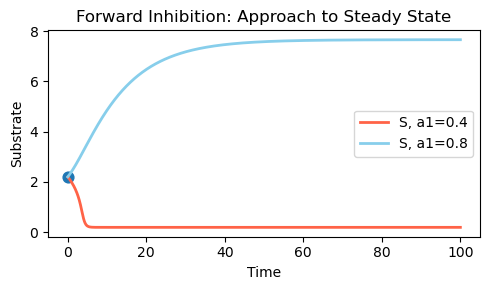

In [5]:
# Two values of the input/production rate a1 to compare: a "low" value
# and a "high" value. We will see that they lead to qualitatively
# different long-term behaviour of S.
a1_pars  = [0.4, 0.8]

a2         = 0.01
b1, b2     = 0.1, 0.01
k_max, K_m = 2, 1
n, m       = 1, 3   # m > n: forward (substrate) inhibition is active

# Initial condition: both simulations start from the same S(0)
S_0 = 2.2

y0 = [S_0]

t_span = (0, 100)


fig, ax = subplots(figsize=(5, 3))

colors = ['tomato', 'skyblue']

# Run one simulation per value of a1 and plot S(t) for each
for index, a1 in enumerate(a1_pars):

    solution = solve_ivp(model, t_span, y0, args=(a1, b1, a2, b2, k_max, K_m, n, m), method='BDF', max_step=0.1)
    
    t = solution.t
    
    S = solution.y.T
        
    ax.plot(t, S, label=f'S, a1={a1}', linewidth=2, color=colors[index])

ax.scatter(0, y0, marker='o', s=60)
ax.set_xlabel('Time')
ax.set_ylabel('Substrate')
ax.legend()
# Both curves approach a steady value (no oscillation here - that is the
# subject of notebook 03). With the same starting point S_0=2.2, the two
# values of a1 lead to very different final levels of S - a first hint of
# the bistability analysed in detail below.
ax.set_title('Forward Inhibition: Approach to Steady State')



fig.tight_layout()

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import cumulative_trapezoid

def dS_dt(S, a1, b1, k_max, K_m, n, m):
    """First equation only - S dynamics independent of P"""
    enzymatic_rate = (k_max * S**n) / (K_m**m + S**m)
    return a1 - b1 * S - enzymatic_rate

def find_steady_states_1D(a1, b1, k_max, K_m, n, m):
    """Find steady states for S equation.

    A steady state S* satisfies dS/dt = 0, i.e. dS_dt(S*, ...) = 0.
    Because dS_dt is nonlinear there is no closed-form solution, so we
    search for roots numerically with fsolve, starting from many
    different initial guesses S_guess spread across the plausible range
    of S. This gives fsolve a chance to find *every* root, not just the
    one nearest to a single starting point. Converged roots are checked
    (positive, residual close to zero) and de-duplicated so that the same
    steady state is not counted twice.
    """
    steady_states = []
    
    # Try multiple initial guesses
    for S_guess in np.linspace(0.1, 15, 50):
        try:
            sol = fsolve(lambda S: dS_dt(S, a1, b1, k_max, K_m, n, m), 
                        S_guess, full_output=True)
            if sol[2] == 1:  # Converged
                S_star = sol[0][0]
                if S_star > 0:  # Positive solution
                    residual = abs(dS_dt(S_star, a1, b1, k_max, K_m, n, m))
                    if residual < 1e-8:
                        # Check if new
                        is_new = True
                        for existing in steady_states:
                            if abs(S_star - existing) < 1e-4:
                                is_new = False
                                break
                        if is_new:
                            steady_states.append(S_star)
        except:
            pass
    
    return sorted(steady_states)

def check_stability_1D(S_star, a1, b1, k_max, K_m, n, m, epsilon=1e-6):
    """Check stability by examining the derivative of dS/dt at the steady state.

    Near a steady state S*, dS/dt ~ f'(S*) * (S - S*). If f'(S*) < 0, any
    small displacement decays back towards S* (stable, a "valley"); if
    f'(S*) > 0, displacements grow (unstable, a "hilltop"). f'(S*) is
    approximated here with a central finite difference.
    """
    # Compute df/dS at steady state
    f_plus = dS_dt(S_star + epsilon, a1, b1, k_max, K_m, n, m)
    f_minus = dS_dt(S_star - epsilon, a1, b1, k_max, K_m, n, m)
    derivative = (f_plus - f_minus) / (2 * epsilon)
    
    # Stable if derivative < 0
    is_stable = derivative < 0
    
    return is_stable, derivative

def compute_potential_1D(a1, b1, k_max, K_m, n, m, S_range=(0.1, 10), resolution=1000):
    """
    Compute 1D potential V(S) such that dS/dt = -dV/dS.

    For a single ODE, dS/dt = f(S) can always be written as the negative
    gradient of a potential V(S): integrating -f(S) over S gives V(S), up
    to an arbitrary additive constant. Stable steady states (f'(S*) < 0)
    become minima ("valleys") of V, and unstable steady states become
    maxima ("hilltops"/barriers) - the "ball rolling in a landscape"
    picture used throughout this notebook.
    """
    S_array = np.linspace(S_range[0], S_range[1], resolution)
    
    # Compute dS/dt for all S values
    dS_dt_array = np.array([dS_dt(S, a1, b1, k_max, K_m, n, m) for S in S_array])
    
    # Integrate to get potential: V(S) = -∫ (dS/dt) dS
    potential = cumulative_trapezoid(-dS_dt_array, S_array, initial=0)
    
    # Shift so minimum is at zero (V is only defined up to an additive
    # constant, so this is purely for a convenient y-axis)
    potential = potential - np.min(potential)
    
    return S_array, potential, dS_dt_array

def plot_1D_potential_comparison():
    """Plot 1D potential for both a1 values side by side.

    Top row: phase portrait dS/dt vs S - where the curve crosses zero are
    the steady states, and the sign of dS/dt on either side shows which
    way S moves.
    Bottom row: the corresponding potential V(S) - the same information
    redrawn as a landscape (valleys = stable, hilltops = unstable).
    """
    
    # Parameters
    b1 = 0.1
    k_max, K_m = 2, 1
    n, m = 1, 3
    a1_values = [0.4, 0.8]
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    
    colors_stable = ['red', 'blue', 'green']
    colors_unstable = ['orange']
    
    for idx, a1 in enumerate(a1_values):
        # Find steady states
        steady_states = find_steady_states_1D(a1, b1, k_max, K_m, n, m)
        
        print(f"\n{'='*50}")
        print(f"a1 = {a1}")
        print(f"{'='*50}")
        print(f"Found {len(steady_states)} steady state(s):")
        
        stable_states = []
        unstable_states = []
        
        for i, S_star in enumerate(steady_states):
            is_stable, derivative = check_stability_1D(S_star, a1, b1, k_max, K_m, n, m)
            stability = "STABLE" if is_stable else "UNSTABLE"
            print(f"  S* = {S_star:.6f}  [{stability}]  (df/dS = {derivative:.6f})")
            
            if is_stable:
                stable_states.append(S_star)
            else:
                unstable_states.append(S_star)


        
        # Compute potential and force
        S_array, potential, force = compute_potential_1D(a1, b1, k_max, K_m, n, m)

        # Top row: Phase portrait (dS/dt vs S)
        ax_phase = axes[0, idx]
        ax_phase.plot(S_array, force, 'g-', linewidth=2.5, label='dS/dt')
        ax_phase.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax_phase.fill_between(S_array, 0, force, where=(force > 0), 
                             alpha=0.3, color='blue', label='S increases')
        ax_phase.fill_between(S_array, 0, force, where=(force < 0), 
                             alpha=0.3, color='red', label='S decreases')
        
        # Mark stable steady states
        for i, S_star in enumerate(stable_states):
            ax_phase.plot(S_star, 0, 'o', color='red', markersize=15,
                         markeredgecolor='white', markeredgewidth=2.5, zorder=5)
            # Add arrows showing stability
            ax_phase.annotate('', xy=(S_star, 0), xytext=(S_star - 0.3, 0),
                            arrowprops=dict(arrowstyle='->', color='red', lw=2))
            ax_phase.annotate('', xy=(S_star, 0), xytext=(S_star + 0.3, 0),
                            arrowprops=dict(arrowstyle='->', color='red', lw=2))
        
        # Mark unstable steady states
        for i, S_star in enumerate(unstable_states):
            ax_phase.plot(S_star, 0, 'X', color='cyan', markersize=15,
                         markeredgecolor='white', markeredgewidth=2.5, zorder=5)
            # Add arrows showing instability
            ax_phase.annotate('', xy=(S_star - 0.3, 0), xytext=(S_star, 0),
                            arrowprops=dict(arrowstyle='->', color='orange', lw=2))
            ax_phase.annotate('', xy=(S_star + 0.3, 0), xytext=(S_star, 0),
                            arrowprops=dict(arrowstyle='->', color='orange', lw=2))
        
        ax_phase.set_xlabel('S (Substrate)', fontsize=12, fontweight='bold')
        ax_phase.set_ylabel('dS/dt (Rate)', fontsize=12, fontweight='bold')
        ax_phase.set_title(f'Phase Portrait (a1={a1})', fontsize=13, fontweight='bold')
        ax_phase.legend(loc='best', fontsize=9)
        ax_phase.grid(True, alpha=0.3)

        
        
        # Bottom row: Potential V(S)
        ax_pot = axes[1, idx]
        ax_pot.plot(S_array, potential, 'b-', linewidth=2.5, label='V(S)')
        ax_pot.fill_between(S_array, 0, potential, alpha=0.3)
        
        # Mark stable steady states on potential
        for i, S_star in enumerate(stable_states):
            V_star = np.interp(S_star, S_array, potential)
            ax_pot.plot(S_star, V_star, 'o', color='red', markersize=15,
                       markeredgecolor='white', markeredgewidth=2.5,
                       label=f'Stable: S*={S_star:.3f}', zorder=5)
        
        # Mark unstable steady states on potential
        for i, S_star in enumerate(unstable_states):
            V_star = np.interp(S_star, S_array, potential)
            ax_pot.plot(S_star, V_star, 'X', color='cyan', markersize=15,
                       markeredgecolor='white', markeredgewidth=2.5,
                       label=f'Unstable: S*={S_star:.3f}', zorder=5)
        
        ax_pot.set_xlabel('S (Substrate)', fontsize=12, fontweight='bold')
        ax_pot.set_ylabel('Potential V(S)', fontsize=12, fontweight='bold')
        ax_pot.set_title(f'Potential Landscape (a1={a1})', fontsize=13, fontweight='bold')
        ax_pot.legend(loc='best', fontsize=9)
        ax_pot.grid(True, alpha=0.3)
        ax_pot.set_ylim(bottom=-0.1)
    
    
    plt.tight_layout()
    # plt.savefig('potential_1D_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_combined_bifurcation(n, m):
    """Plot bifurcation diagram showing the transition from monostable to bistable.

    Repeats the steady-state + stability analysis above for a whole range
    of a1 values, then plots S* against a1. Stable branches (red dots) and
    the unstable branch (cyan crosses) trace out the bifurcation diagram;
    wherever a branch appears or disappears marks a bifurcation point.
    """
    
    b1 = 0.1
    k_max, K_m = 2, 1
    
    # Scan a1 values
    a1_values = np.linspace(0.3, 1.5, 100)
    
    all_stable = []
    all_unstable = []
    all_a1_stable = []
    all_a1_unstable = []
    
    for a1 in a1_values:
        steady_states = find_steady_states_1D(a1, b1, k_max, K_m, n, m)
        
        for S_star in steady_states:
            is_stable, _ = check_stability_1D(S_star, a1, b1, k_max, K_m, n, m)
            
            if is_stable:
                all_stable.append(S_star)
                all_a1_stable.append(a1)
            else:
                all_unstable.append(S_star)
                all_a1_unstable.append(a1)
    
    # Plot bifurcation diagram
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    if all_a1_stable:
        ax.plot(all_a1_stable, all_stable, 'o', color='red', 
               markersize=3, label='Stable steady states', alpha=0.7)
    if all_a1_unstable:
    # if all_a1_unstable and (m>2):
        ax.plot(all_a1_unstable, all_unstable, 'x', color='cyan', 
               markersize=4, label='Unstable steady state', alpha=0.7)
    
    ax.axvline(x=0.4, color='gray', linestyle='--', linewidth=2, 
              alpha=0.5, label='a1=0.4')
    ax.axvline(x=0.8, color='black', linestyle='--', linewidth=2, 
              alpha=0.5, label='a1=0.8')
 
    ax.set_xlabel('a1 (control parameter)', fontsize=12, fontweight='bold')
    ax.set_ylabel('S* (steady state)', fontsize=12, fontweight='bold')
    ax.set_title('Bifurcation Diagram: Saddle-Node Bifurcation', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Textbox 1
    textstr = f'n={n}, m={m}'
    
    # Define the style of the textbox using a dictionary
    props = dict(
        boxstyle='round,pad=0.5', 
        facecolor='wheat', 
        alpha=0.5, 
        edgecolor='gray'
    )
    
    # Place the text box in the upper left of the axes
    ax.text(
        0.55, 0.92, textstr, 
        transform=ax.transAxes, 
        fontsize=10,
        verticalalignment='top', 
        bbox=props
    );
    
    plt.tight_layout()
    # plt.savefig('bifurcation_diagram_1D.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the analysis
print("="*37)
print("|| 1D POTENTIAL LANDSCAPE ANALYSIS ||")
print("="*37)

|| 1D POTENTIAL LANDSCAPE ANALYSIS ||


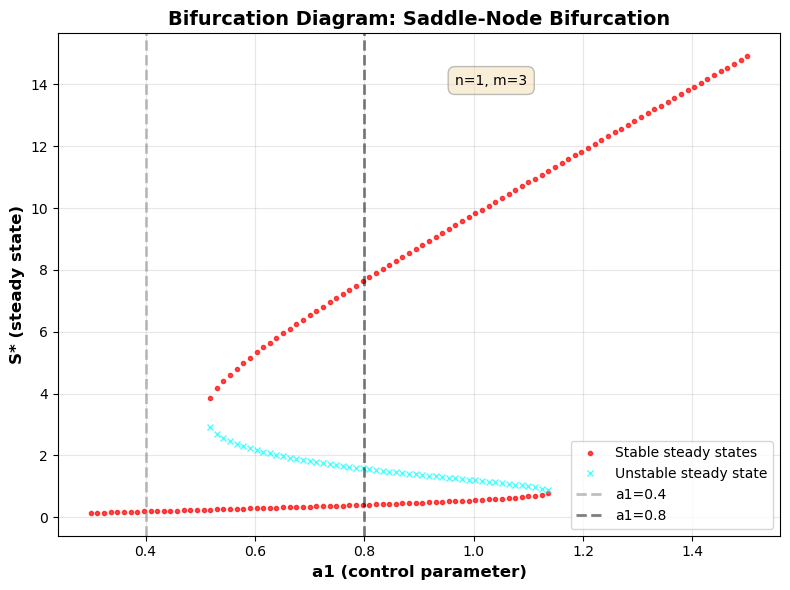

In [7]:
# Generate the bifurcation diagram defined above: S* vs a1, with the
# stable branches in red and the unstable branch in cyan. See the markdown
# cell below for how to read this plot.
n, m = 1, 3

plot_combined_bifurcation(n, m)


# Guyton Figure Recreation

Upper stable SS (healthy): 6.533
Unstable threshold:        1.820
Lower stable SS (death):   0.347

Small bleed Δ = 4.03  → S₀ after = 2.506
Large bleed Δ = 5.67  → S₀ after = 0.866


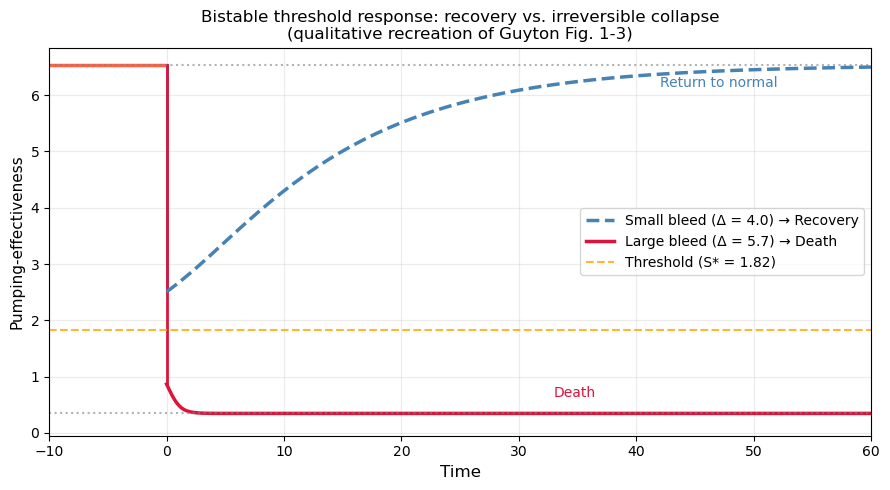

In [8]:
# =============================================================================
# GUYTON FIGURE RECREATION: Bistable perturbation — recovery vs. collapse
# =============================================================================
#
# Qualitative recreation of Guyton Figure 1-3.
# The system is placed at the upper stable steady state (the 'healthy' state).
# Two 'bleeding' events are modelled as instantaneous drops in S at t=0:
#   - Small bleed: S stays above the unstable threshold → recovery
#   - Large bleed: S falls below the unstable threshold → irreversible collapse
#
# The key parameters to tune the visual appearance:
#   a1_bistable  : must be inside the bistable window (from bifurcation diagram)
#   bleed_small  : size of the sub-threshold perturbation
#   bleed_large  : size of the supra-threshold perturbation
#   t_end        : how long to simulate after the bleed
# =============================================================================

# --- Parameters (same kinetics as the rest of the notebook) ---
a1_bistable = 0.7   # a1 value inside the bistable regime
b1          = 0.1
a2, b2      = 0.01, 0.01   # P parameters — required by model() but unused in dS/dt
k_max, K_m  = 2, 1
n, m        = 1, 3

# --- Locate the three steady states at a1_bistable ---
ss_all = find_steady_states_1D(a1_bistable, b1, k_max, K_m, n, m)

stable_ss   = [s for s in ss_all
               if check_stability_1D(s, a1_bistable, b1, k_max, K_m, n, m)[0]]
unstable_ss = [s for s in ss_all
               if not check_stability_1D(s, a1_bistable, b1, k_max, K_m, n, m)[0]]

low_ss    = min(stable_ss)    # lower stable ("death" attractor)
high_ss   = max(stable_ss)    # upper stable ("healthy" attractor)
threshold = unstable_ss[0]    # separatrix / tipping point

print(f'Upper stable SS (healthy): {high_ss:.3f}')
print(f'Unstable threshold:        {threshold:.3f}')
print(f'Lower stable SS (death):   {low_ss:.3f}')

# --- Define bleed sizes ---
# Small bleed: lands midway between high_ss and threshold → recovers
# Large bleed: lands midway between threshold and low_ss  → collapses
bleed_small = high_ss - 0.3 * (high_ss + threshold)   # adjust freely
bleed_large = high_ss - 0.4 * (threshold + low_ss)    # adjust freely

print(f'\nSmall bleed Δ = {bleed_small:.2f}  → S₀ after = {high_ss - bleed_small:.3f}')
print(f'Large bleed Δ = {bleed_large:.2f}  → S₀ after = {high_ss - bleed_large:.3f}')

# --- Simulate both scenarios after the bleed ---
t_end   = 60    # time units after bleed (long enough to see full recovery or collapse)
t_pre   = 10     # flat segment before the bleed

sol_small = solve_ivp(
    model, (0, t_end), [high_ss - bleed_small],
    args=(a1_bistable, b1, a2, b2, k_max, K_m, n, m),
    method='BDF', max_step=1.0
)
sol_large = solve_ivp(
    model, (0, t_end), [high_ss - bleed_large],
    args=(a1_bistable, b1, a2, b2, k_max, K_m, n, m),
    method='BDF', max_step=1.0
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))

# Pre-bleed flat segment at upper SS
ax.hlines(high_ss, -t_pre, 0, color='tomato', linewidth=2.5)

# Instantaneous drop at t=0 (the bleed)
ax.plot([0, 0], [high_ss, high_ss - bleed_small],
        color='steelblue', linewidth=2)
ax.plot([0, 0], [high_ss, high_ss - bleed_large],
        color='crimson', linewidth=2)

# Post-bleed trajectories
ax.plot(sol_small.t, sol_small.y[0],
        color='steelblue', linewidth=2.5, linestyle='--',
        label=f'Small bleed (\u0394 = {bleed_small:.1f}) \u2192 Recovery')
ax.plot(sol_large.t, sol_large.y[0],
        color='crimson', linewidth=2.5,
        label=f'Large bleed (\u0394 = {bleed_large:.1f}) \u2192 Death')

# Reference lines for steady states and threshold
ax.axhline(y=high_ss,   color='gray', linestyle=':',  alpha=0.6)
ax.axhline(y=threshold, color='orange', linestyle='--', alpha=0.8,
           label=f'Threshold (S* = {threshold:.2f})')
ax.axhline(y=low_ss,    color='gray', linestyle=':',  alpha=0.6)

# Text annotations
ax.text(t_end * 0.7, high_ss * 0.97, 'Return to normal',
        color='steelblue', fontsize=10, va='top')
ax.text(t_end * 0.55, low_ss + (threshold - low_ss) * 0.2, 'Death',
        color='crimson', fontsize=10)

ax.set_xlabel('Time', fontsize=12)
ax.set_ylabel('Pumping-effectiveness', fontsize=11)
ax.set_title(
    'Bistable threshold response: recovery vs. irreversible collapse\n'
    '(qualitative recreation of Guyton Fig. 1-3)',
    fontsize=12
)
ax.legend(fontsize=10, loc='center right')
ax.set_xlim([-t_pre, t_end])
ax.set_ylim(bottom=-0.05)
ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


# Backward activation

In [21]:
def backward_activation_model(t, S, a_s, b_s, k_max, K_m, n):
    """Enzymatic Reaction with forward inhibition

    This is a 1-variable reduction of the 2-variable model used in
    the notebook on enzymatic oscillations: here we track only the substrate S
    and ignore the downstream product P because it is not having an effect on the rate. This is a simplifying assumption, not necessarily the reality. a2 and b2 are accepted as
    arguments (so the function signature matches the 2-variable version)
    but are not used in the right-hand side below.

    t    : time (unused, but required by solve_ivp's function signature)
    S    : current substrate concentration
    a1   : constant input/production rate of S (the "control parameter"
           we vary throughout this notebook)
    b1   : linear removal rate of S (e.g. dilution, degradation)
    k_max, K_m, n, m : Hill/Haldane kinetics parameters, as in the
           kinetics() function above (forward inhibition: m > n)
    """

    # Nonlinear consumption of S by the enzyme, including forward
    # (substrate) inhibition at high S - same functional form as
    # kinetics(S, k_max, K_m, n, m) used earlier for the rate surfaces.
    enzymatic_rate = k_max * S**n / (K_m + S**n)

    # Net rate of change of S: constant inflow (a1), linear outflow
    # (b1 * S), plus the nonlinear autocatalytic production.
    dSdt = a_s - b_s * S + enzymatic_rate

    return dSdt

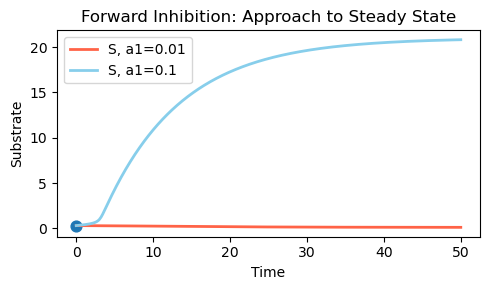

In [33]:
# Two values of the input/production rate a1 to compare: a "low" value
# and a "high" value. We will see that they lead to qualitatively
# different long-term behaviour of S.
a1_pars  = [0.01, 0.1]

b1     = 0.1
k_max, K_m = 2, 1
n          = 4   # m > n: forward (substrate) inhibition is active

# Initial condition: both simulations start from the same S(0)
S_0 = 0.3

y0 = [S_0]

t_span = (0, 50)


fig, ax = subplots(figsize=(5, 3))

colors = ['tomato', 'skyblue']

# Run one simulation per value of a1 and plot S(t) for each
for index, a1 in enumerate(a1_pars):

    solution = solve_ivp(backward_activation_model, t_span, y0, args=(a1, b1, k_max, K_m, n), method='BDF', max_step=0.1)
    
    t = solution.t
    
    S = solution.y.T
        
    ax.plot(t, S, label=f'S, a1={a1}', linewidth=2, color=colors[index])

ax.scatter(0, y0, marker='o', s=60)
ax.set_xlabel('Time')
ax.set_ylabel('Substrate')
ax.legend()
# Both curves approach a steady value (no oscillation here - that is the
# subject of notebook 03). With the same starting point S_0=2.2, the two
# values of a1 lead to very different final levels of S - a first hint of
# the bistability analysed in detail below.
ax.set_title('Forward Inhibition: Approach to Steady State')



fig.tight_layout()

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.integrate import cumulative_trapezoid

def dS_dt(S, a1, b1, k_max, K_m, n):
    """First equation only - S dynamics independent of P"""
    
    enzymatic_rate = (k_max * S**n) / (K_m + S**n)
    
    return a1 - b1 * S + enzymatic_rate

def find_steady_states_1D(a1, b1, k_max, K_m, n):
    """Find steady states for S equation.

    A steady state S* satisfies dS/dt = 0, i.e. dS_dt(S*, ...) = 0.
    Because dS_dt is nonlinear there is no closed-form solution, so we
    search for roots numerically with fsolve, starting from many
    different initial guesses S_guess spread across the plausible range
    of S. This gives fsolve a chance to find *every* root, not just the
    one nearest to a single starting point. Converged roots are checked
    (positive, residual close to zero) and de-duplicated so that the same
    steady state is not counted twice.
    """
    steady_states = []
    
    # Try multiple initial guesses
    for S_guess in np.linspace(0.1, 15, 50):
        try:
            sol = fsolve(lambda S: dS_dt(S, a1, b1, k_max, K_m, n), 
                        S_guess, full_output=True)
            if sol[2] == 1:  # Converged
                S_star = sol[0][0]
                if S_star > 0:  # Positive solution
                    residual = abs(dS_dt(S_star, a1, b1, k_max, K_m, n))
                    if residual < 1e-8:
                        # Check if new
                        is_new = True
                        for existing in steady_states:
                            if abs(S_star - existing) < 1e-4:
                                is_new = False
                                break
                        if is_new:
                            steady_states.append(S_star)
        except:
            pass
    
    return sorted(steady_states)

def check_stability_1D(S_star, a1, b1, k_max, K_m, n, epsilon=1e-6):
    """Check stability by examining the derivative of dS/dt at the steady state.

    Near a steady state S*, dS/dt ~ f'(S*) * (S - S*). If f'(S*) < 0, any
    small displacement decays back towards S* (stable, a "valley"); if
    f'(S*) > 0, displacements grow (unstable, a "hilltop"). f'(S*) is
    approximated here with a central finite difference.
    """
    # Compute df/dS at steady state
    f_plus = dS_dt(S_star + epsilon, a1, b1, k_max, K_m, n)
    f_minus = dS_dt(S_star - epsilon, a1, b1, k_max, K_m, n)
    derivative = (f_plus - f_minus) / (2 * epsilon)
    
    # Stable if derivative < 0
    is_stable = derivative < 0
    
    return is_stable, derivative

def compute_potential_1D(a1, b1, k_max, K_m, n, S_range=(0.1, 10), resolution=1000):
    """
    Compute 1D potential V(S) such that dS/dt = -dV/dS.

    For a single ODE, dS/dt = f(S) can always be written as the negative
    gradient of a potential V(S): integrating -f(S) over S gives V(S), up
    to an arbitrary additive constant. Stable steady states (f'(S*) < 0)
    become minima ("valleys") of V, and unstable steady states become
    maxima ("hilltops"/barriers) - the "ball rolling in a landscape"
    picture used throughout this notebook.
    """
    S_array = np.linspace(S_range[0], S_range[1], resolution)
    
    # Compute dS/dt for all S values
    dS_dt_array = np.array([dS_dt(S, a1, b1, k_max, K_m, n) for S in S_array])
    
    # Integrate to get potential: V(S) = -∫ (dS/dt) dS
    potential = cumulative_trapezoid(-dS_dt_array, S_array, initial=0)
    
    # Shift so minimum is at zero (V is only defined up to an additive
    # constant, so this is purely for a convenient y-axis)
    potential = potential - np.min(potential)
    
    return S_array, potential, dS_dt_array

def plot_1D_potential_comparison():
    """Plot 1D potential for both a1 values side by side.

    Top row: phase portrait dS/dt vs S - where the curve crosses zero are
    the steady states, and the sign of dS/dt on either side shows which
    way S moves.
    Bottom row: the corresponding potential V(S) - the same information
    redrawn as a landscape (valleys = stable, hilltops = unstable).
    """
    
    # Parameters
    b1 = 0.1
    k_max, K_m = 2, 1
    n = 2
    a1_values = [0.05, 0.12]
    
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    
    colors_stable = ['red', 'blue', 'green']
    colors_unstable = ['orange']
    
    for idx, a1 in enumerate(a1_values):
        # Find steady states
        steady_states = find_steady_states_1D(a1, b1, k_max, K_m, n)
        
        print(f"\n{'='*50}")
        print(f"a1 = {a1}")
        print(f"{'='*50}")
        print(f"Found {len(steady_states)} steady state(s):")
        
        stable_states = []
        unstable_states = []
        
        for i, S_star in enumerate(steady_states):
            is_stable, derivative = check_stability_1D(S_star, a1, b1, k_max, K_m, n)
            stability = "STABLE" if is_stable else "UNSTABLE"
            print(f"  S* = {S_star:.6f}  [{stability}]  (df/dS = {derivative:.6f})")
            
            if is_stable:
                stable_states.append(S_star)
            else:
                unstable_states.append(S_star)


        
        # Compute potential and force
        S_array, potential, force = compute_potential_1D(a1, b1, k_max, K_m, n)

        # Top row: Phase portrait (dS/dt vs S)
        ax_phase = axes[0, idx]
        ax_phase.plot(S_array, force, 'g-', linewidth=2.5, label='dS/dt')
        ax_phase.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
        ax_phase.fill_between(S_array, 0, force, where=(force > 0), 
                             alpha=0.3, color='blue', label='S increases')
        ax_phase.fill_between(S_array, 0, force, where=(force < 0), 
                             alpha=0.3, color='red', label='S decreases')
        
        # Mark stable steady states
        for i, S_star in enumerate(stable_states):
            ax_phase.plot(S_star, 0, 'o', color='red', markersize=15,
                         markeredgecolor='white', markeredgewidth=2.5, zorder=5)
            # Add arrows showing stability
            ax_phase.annotate('', xy=(S_star, 0), xytext=(S_star - 0.3, 0),
                            arrowprops=dict(arrowstyle='->', color='red', lw=2))
            ax_phase.annotate('', xy=(S_star, 0), xytext=(S_star + 0.3, 0),
                            arrowprops=dict(arrowstyle='->', color='red', lw=2))
        
        # Mark unstable steady states
        for i, S_star in enumerate(unstable_states):
            ax_phase.plot(S_star, 0, 'X', color='cyan', markersize=15,
                         markeredgecolor='white', markeredgewidth=2.5, zorder=5)
            # Add arrows showing instability
            ax_phase.annotate('', xy=(S_star - 0.3, 0), xytext=(S_star, 0),
                            arrowprops=dict(arrowstyle='->', color='orange', lw=2))
            ax_phase.annotate('', xy=(S_star + 0.3, 0), xytext=(S_star, 0),
                            arrowprops=dict(arrowstyle='->', color='orange', lw=2))
        
        ax_phase.set_xlabel('S (Substrate)', fontsize=12, fontweight='bold')
        ax_phase.set_ylabel('dS/dt (Rate)', fontsize=12, fontweight='bold')
        ax_phase.set_title(f'Phase Portrait (a1={a1})', fontsize=13, fontweight='bold')
        ax_phase.legend(loc='best', fontsize=9)
        ax_phase.grid(True, alpha=0.3)

        
        
        # Bottom row: Potential V(S)
        ax_pot = axes[1, idx]
        ax_pot.plot(S_array, potential, 'b-', linewidth=2.5, label='V(S)')
        ax_pot.fill_between(S_array, 0, potential, alpha=0.3)
        
        # Mark stable steady states on potential
        for i, S_star in enumerate(stable_states):
            V_star = np.interp(S_star, S_array, potential)
            ax_pot.plot(S_star, V_star, 'o', color='red', markersize=15,
                       markeredgecolor='white', markeredgewidth=2.5,
                       label=f'Stable: S*={S_star:.3f}', zorder=5)
        
        # Mark unstable steady states on potential
        for i, S_star in enumerate(unstable_states):
            V_star = np.interp(S_star, S_array, potential)
            ax_pot.plot(S_star, V_star, 'X', color='cyan', markersize=15,
                       markeredgecolor='white', markeredgewidth=2.5,
                       label=f'Unstable: S*={S_star:.3f}', zorder=5)
        
        ax_pot.set_xlabel('S (Substrate)', fontsize=12, fontweight='bold')
        ax_pot.set_ylabel('Potential V(S)', fontsize=12, fontweight='bold')
        ax_pot.set_title(f'Potential Landscape (a1={a1})', fontsize=13, fontweight='bold')
        ax_pot.legend(loc='best', fontsize=9)
        ax_pot.grid(True, alpha=0.3)
        ax_pot.set_ylim(bottom=-0.1)
    
    
    plt.tight_layout()
    # plt.savefig('potential_1D_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_combined_bifurcation_2(n):
    """Plot bifurcation diagram showing the transition from monostable to bistable.

    Repeats the steady-state + stability analysis above for a whole range
    of a1 values, then plots S* against a1. Stable branches (red dots) and
    the unstable branch (cyan crosses) trace out the bifurcation diagram;
    wherever a branch appears or disappears marks a bifurcation point.
    """
    
    b1 = 0.5
    k_max, K_m = 2, 1
    
    # Scan a1 values
    a1_values = np.linspace(0.0, 0.25, 100)
    
    all_stable = []
    all_unstable = []
    all_a1_stable = []
    all_a1_unstable = []
    
    for a1 in a1_values:
        steady_states = find_steady_states_1D(a1, b1, k_max, K_m, n)
        
        for S_star in steady_states:
            is_stable, _ = check_stability_1D(S_star, a1, b1, k_max, K_m, n)
            
            if is_stable:
                all_stable.append(S_star)
                all_a1_stable.append(a1)
            else:
                all_unstable.append(S_star)
                all_a1_unstable.append(a1)
    
    # Plot bifurcation diagram
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    
    if all_a1_stable:
        ax.plot(all_a1_stable, all_stable, 'o', color='red', 
               markersize=3, label='Stable steady states', alpha=0.7)
    if all_a1_unstable:
    # if all_a1_unstable and (m>2):
        ax.plot(all_a1_unstable, all_unstable, 'x', color='cyan', 
               markersize=4, label='Unstable steady state', alpha=0.7)
    
    ax.axvline(x=0.05, color='gray', linestyle='--', linewidth=2, 
              alpha=0.5, label='a1=0.05')
    ax.axvline(x=0.12, color='black', linestyle='--', linewidth=2, 
              alpha=0.5, label='a1=0.12')
 
    ax.set_xlabel('a1 (control parameter)', fontsize=12, fontweight='bold')
    ax.set_ylabel('S* (steady state)', fontsize=12, fontweight='bold')
    ax.set_title('Bifurcation Diagram: Saddle-Node Bifurcation', 
                fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    # Textbox 1
    textstr = f'n={n}'
    
    # Define the style of the textbox using a dictionary
    props = dict(
        boxstyle='round,pad=0.5', 
        facecolor='wheat', 
        alpha=0.5, 
        edgecolor='gray'
    )
    
    # Place the text box in the upper left of the axes
    ax.text(
        0.55, 0.92, textstr, 
        transform=ax.transAxes, 
        fontsize=10,
        verticalalignment='top', 
        bbox=props
    );
    
    plt.tight_layout()
    # plt.savefig('bifurcation_diagram_1D.png', dpi=300, bbox_inches='tight')
    plt.show()

# Run the analysis
print("="*37)
print("|| 1D POTENTIAL LANDSCAPE ANALYSIS ||")
print("="*37)

|| 1D POTENTIAL LANDSCAPE ANALYSIS ||


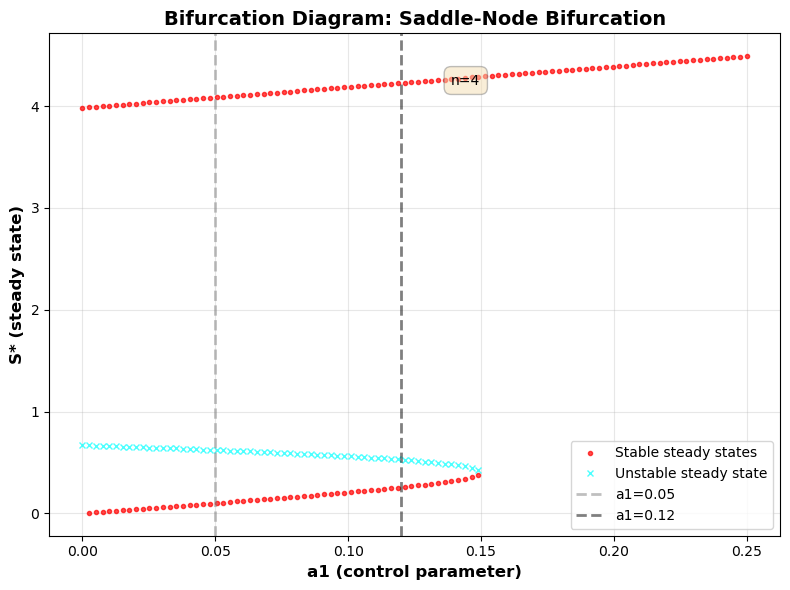

In [40]:
n = 4

plot_combined_bifurcation_2(n)